## Access Animal Acoustic Tracking Delayed Summarised Detection Qc (Parquet)
This Jupyter notebook demonstrates how to access and plot animal_acoustic_tracking_delayed_summarised_detection_qc data, available as a [Parquet](https://parquet.apache.org) dataset stored on S3.

🔗 More information about the dataset is available [in the AODN metadata catalogue](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/c524d3dd-536e-452c-b8e8-cd0e8901ea67).

📌 The source of truth for this notebook is maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/tree/main/notebooks/animal_acoustic_tracking_delayed_summarised_detection_qc.ipynb).


In [21]:
dataset_name = "animal_acoustic_tracking_delayed_summarised_detection_qc"

## Install/Update packages and Load common functions

In [22]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

✅ Virtual environment already exists, skipping creation.


Using Python 3.12.11 environment at: /home/ecougnon/anaconda3/envs/AodnCloudOptimised
Resolved 201 packages in 752ms
Audited 201 packages in 1ms


✅ Local version 0.3.31 is up to date (remote: 0.3.30)


/home/ecougnon/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:4865: UserWarning: registration of accessor <class 'DataQuery.AODNAccessor'> under name 'aodn' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("aodn")


In [23]:
from DataQuery import GetAodn

# Understanding the Dataset

## Understanding Parquet Partitioning

Parquet files can be **partitioned** by one or more columns, which means the data is physically organised into folders based on the values in those columns. This is similar to how databases use indexes to optimise query performance.

Partitioning enables **faster filtering**: when you query data using a partitioned column, only the relevant subset of files needs to be read—improving performance significantly.

For example, if a dataset is partitioned by `"site_code"`, `"timestamp"`, and `"polygon"`, filtering on `"site_code"` allows the system to skip unrelated files entirely.

In this notebook, the `GetAodn` class includes built-in methods to efficiently filter data by **time** and **latitude/longitude** using the **timestamp** and **polygon** partitions. Other partitions can be used for filtering via the `scalar_filter`.

Any filtering on columns that are **not** partitioned can be significantly slower, as all files may need to be scanned. However, the `GetAodn` class provides a `scalar_filter` method that lets you apply these filters at load time—before the data is fully read—helping reduce the size of the resulting DataFrame.

Once the dataset is loaded, further filtering using Pandas is efficient and flexible.

See further below in the notebook for examples of how to filter the data effectively.

To view the actual partition columns for this dataset, run:


In [24]:
aodn = GetAodn()
dname = f'{dataset_name}.parquet'
%time aodn_dataset = aodn.get_dataset(dname)

CPU times: user 486 ms, sys: 3.41 ms, total: 489 ms
Wall time: 487 ms


In [25]:
aodn_dataset.dataset.partitioning.schema

timestamp: int32
polygon: string

## List unique partition values

In [26]:
%%time
unique_partition_value = aodn_dataset.get_unique_partition_values('YOUR_PARTITION_KEY')
print(list(unique_partition_value)[0:2])  # showing a subset only

[]
CPU times: user 19 ms, sys: 5.03 ms, total: 24.1 ms
Wall time: 20 ms


## Visualise Spatial Extent of the dataset
This section plots the polygons representing the areas where data is available. It helps to identify and create a bounding box around the regions containing data.

/home/ecougnon/anaconda3/envs/AodnCloudOptimised/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


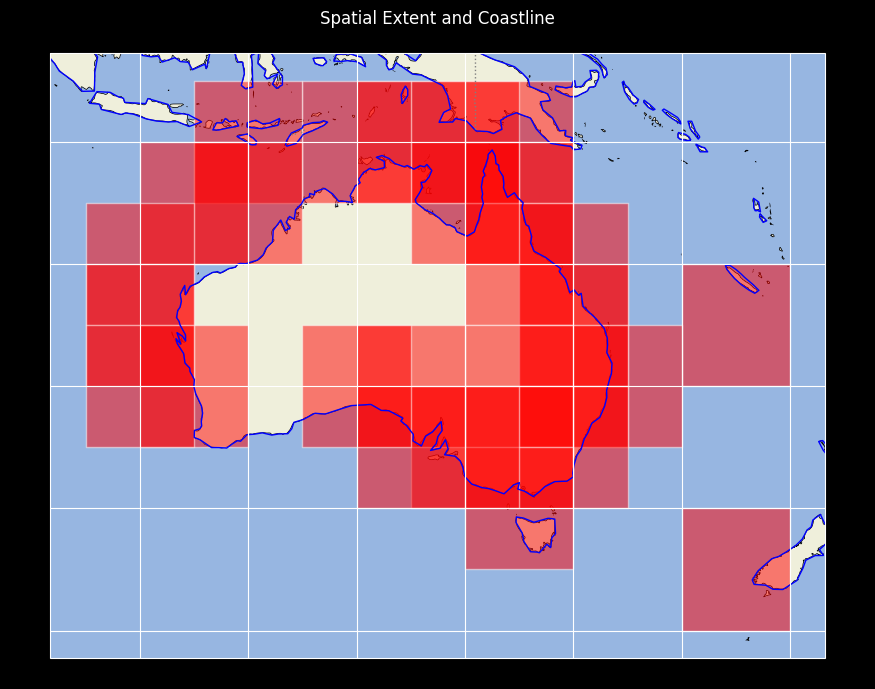

In [8]:
aodn_dataset.plot_spatial_extent()

## Get Temporal Extent of the dataset

Similarly to the spatial extent, we're retrieving the minimum and maximum timestamp partition values of the dataset. This is not necessarily an accurate representation of the TIME values, as the timestamp partition can be yearly/monthly... but is here to give an idea

In [9]:
%%time
aodn_dataset.get_temporal_extent()

CPU times: user 177 ms, sys: 39.4 ms, total: 216 ms
Wall time: 603 ms


(Timestamp('2007-08-08 07:00:00'), Timestamp('2026-07-11 23:00:00'))

## Read Metadata

For all Parquet datasets, we create a sidecar file named **_common_metadata** in the root of the dataset. This file contains both the dataset-level and variable-level attributes.  
The metadata can be retrieved below as a dictionary, and it will also be included in the pandas DataFrame when using the `get_data` method from the `GetAodn` class.

In [27]:
metadata = aodn_dataset.get_metadata()
metadata

2026-10-09 14:53:57,352 - aodn.GetAodn - INFO - Retrieving metadata for aodn-cloud-optimised/animal_acoustic_tracking_delayed_summarised_detection_qc.parquet


{'polygon': {'type': 'string',
  'units': '1',
  'long_name': 'Spatial partition polygon'},
 'filename': {'type': 'string',
  'units': '1',
  'long_name': 'Filename of the source file'},
 'animal_id': {'type': 'string',
  'units': '',
  'comments': 'Unique identifier for the animal carrying the transmitter. This is a combination of the transmitter ID(s), the animal ID and the deployment ID in the IMOS Australian Animal Acoustic Telemetry Database.',
  'long_name': '',
  'standard_name': ''},
 'timestamp': {'type': 'int64',
  'units': '1',
  'long_name': 'Partition timestamp'},
 'animal_sex': {'type': 'string',
  'units': '',
  'comments': 'Animal sex (e.g. m; f; NA)',
  'long_name': '',
  'standard_name': ''},
 'measurement': {'type': 'string',
  'units': '',
  'comments': 'Measurement type of the animal tagged with its value and unit',
  'long_name': '',
  'standard_name': ''},
 'station_name': {'type': 'string',
  'units': '',
  'comments': 'Station name within the installation where

# Data Query and Plot

## Create a TIME and BoundingBox filter

This cell loads a subset of the dataset based on a time range and a spatial bounding box. The result is returned as a pandas DataFrame, and basic information about its structure is displayed.

In [11]:
%%time
df_time_bb = aodn_dataset.get_data(date_start='2022-12-01',
                                   date_end='2023-01-01',
                                   lat_min=-34,
                                   lat_max=-28,
                                   lon_min=151,
                                   lon_max=160,
                                   )

df_time_bb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239 entries, 0 to 238
Data columns (total 31 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   filename                             239 non-null    object        
 1   animal_id                            239 non-null    object        
 2   animal_sex                           239 non-null    object        
 3   measurement                          239 non-null    object        
 4   station_name                         239 non-null    object        
 5   date_hour_UTC                        239 non-null    datetime64[ns]
 6   nb_detections                        239 non-null    int32         
 7   receiver_name                        239 non-null    object        
 8   CAAB_species_id                      239 non-null    int32         
 9   installation_name                    239 non-null    object        
 10  species_common

In [12]:
print(f'List of species with detections during the defined time and within the defined bounding box: {df_time_bb['species_common_name'].unique()}')
#df_time_bb['species_common_name'].unique()

List of species with detections during the defined time and within the defined bounding box: ['Greynurse Shark' 'Bull Shark' 'Zebra Shark']


## Create a species filter that is not a partition

As species is not a partitioned column, the filtering is done after the data is loaded into memory, which can be slower for large datasets.

The cells below explore the different species available in the parquet dataset and load a subset of the dataset based on a single species. The result is returned as a pandas DataFrame, and basic information about its structure is displayed.

In [16]:
df_list_species = aodn_dataset.get_data(columns=['species_common_name'])
df_list_species['species_common_name'].unique()

array(['Bluethroat Wrasse'], dtype=object)

If the species of interest is known, the best approach is to use the `scalar_filter` parameter in the `get_data` method, which allows filtering on non-partitioned columns at load time. This can significantly reduce the size of the resulting DataFrame and improve performance. Example below

In [19]:
df_BluethroatWrasse = aodn_dataset.get_data(date_start='2010-01-01',
                                            date_end='2017-12-31',
                                            scalar_filter={'species_common_name': 'Bluethroat Wrasse'})
df_BluethroatWrasse.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 31 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   filename                             24 non-null     object        
 1   animal_id                            24 non-null     object        
 2   animal_sex                           24 non-null     object        
 3   measurement                          24 non-null     object        
 4   station_name                         24 non-null     object        
 5   date_hour_UTC                        24 non-null     datetime64[ns]
 6   nb_detections                        24 non-null     int32         
 7   receiver_name                        24 non-null     object        
 8   CAAB_species_id                      24 non-null     int32         
 9   installation_name                    24 non-null     object        
 10  species_common_n

In [20]:
## Download Subsetted Data as CSV

# This cell downloads the filtered dataset as a ZIP-compressed CSV file.  
# The CSV includes metadata at the top as commented lines, and a `FileLink` object is returned to allow downloading directly from the notebook.

df_BluethroatWrasse.aodn.download_as_csv()

/home/ecougnon/github_repo/aodn_cloud_optimised/notebooks/aodn_metadata-uuid_c524d3dd-536e-452c-b8e8-cd0e8901ea67_animal_acoustic_tracking_delayed_summarised_detection_qc_data-hash_125e3d79.csv.zip